# 02 Initial EDA and Theme Discovery

## Purpose

This notebook is the main Task 2 notebook for initial exploratory text analysis on the cleaned earnings-call transcript corpus.

It is designed to:
- load the cleaned Task 1 transcript dataset
- describe the corpus at a basic descriptive level
- explore interpretable keyword and concept frequencies
- inspect simple bag-of-words summaries
- fit a lightweight exploratory topic model
- show the main results directly in the notebook and also save them to stable project paths

## Source Modules and Functions Used

- `src/data/load_transcripts.py`
  - `load_raw_transcripts`
- `src/features/keyword_counts.py`
  - `DEFAULT_CONCEPT_KEYWORDS`
  - `build_keyword_feature_table`
  - `keyword_frequency_summary`
  - `keyword_frequency_by_year`
  - `keyword_frequency_by_firm`
  - `build_term_frequency_table`
- `src/features/topic_modeling.py`
  - `prepare_documents_for_topic_modeling`
  - `sample_topic_documents`
  - `fit_lda_topic_model`
  - `extract_top_words_per_topic`
  - `assign_dominant_topic`
  - `summarize_topic_prevalence`
  - `select_topic_examples`
- `src/utils/paths.py`
  - `ensure_project_dirs`
  - `processed_data_path`
  - `interim_data_path`
  - `table_path`
  - `figure_path`

## Expected Inputs

- the cleaned Task 1 transcript dataset in `data/processed/`
- transcript-level fields for text, date, firm, ticker, and transcript identifier

## Outputs Written and Displayed

- counts and summary tables displayed in the notebook and saved to `outputs/tables/`
- figures displayed in the notebook and saved to `outputs/figures/`
- transcript-level keyword features and sampled topic assignments saved to `data/interim/`


In [8]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

# Make the repository root importable so `src/` works in Jupyter.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT_CANDIDATES = [NOTEBOOK_DIR, NOTEBOOK_DIR.parent]
PROJECT_ROOT = next(
    (candidate for candidate in PROJECT_ROOT_CANDIDATES if (candidate / "src").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the repository root containing `src/`.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.data.load_transcripts import load_raw_transcripts
from src.features.keyword_counts import (
    DEFAULT_CONCEPT_KEYWORDS,
    build_keyword_feature_table,
    build_term_frequency_table,
    keyword_frequency_by_firm,
    keyword_frequency_by_year,
    keyword_frequency_summary,
)
from src.features.topic_modeling import (
    assign_dominant_topic,
    extract_top_words_per_topic,
    fit_lda_topic_model,
    prepare_documents_for_topic_modeling,
    sample_topic_documents,
    select_topic_examples,
    summarize_topic_prevalence,
)
from src.utils.paths import ensure_project_dirs, figure_path, interim_data_path, processed_data_path, table_path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")
ensure_project_dirs()

load_nrows_env = os.environ.get("TASK2_LOAD_NROWS")
LOAD_NROWS = int(load_nrows_env) if load_nrows_env else None
TOPIC_SAMPLE_SIZE = int(os.environ.get("TASK2_TOPIC_SAMPLE_SIZE", "4000"))
TOPIC_COUNT = int(os.environ.get("TASK2_TOPIC_COUNT", "6"))
OUTPUT_PREFIX = "02_initial_eda"
TEXT_COLUMN = "full_transcript_text"
DATE_COLUMN = "call_date"
FIRM_COLUMN = "companyname"
TICKER_COLUMN = "ticker"
ID_COLUMN = "transcriptid"
TEXT_METRIC_COLUMNS = ["word_count", "transcript_length"]
CONCEPT_KEYWORDS = DEFAULT_CONCEPT_KEYWORDS
TRANSCRIPT_COLUMNS = [
    ID_COLUMN,
    FIRM_COLUMN,
    TICKER_COLUMN,
    DATE_COLUMN,
    TEXT_COLUMN,
    "word_count",
    "transcript_length",
    "event_type",
]

cleaned_candidates = [
    processed_data_path("01_data_audit_cleaned_transcripts.parquet"),
    processed_data_path("CLEANED_earnings_calls_full_2010_onward_with_revenue.csv"),
    processed_data_path("CLEANED_earnings_calls_full_5year_with_revenue.csv"),
]
CLEANED_PATH = next((path for path in cleaned_candidates if path.exists()), cleaned_candidates[0])

print(f"Project root: {PROJECT_ROOT}")
print(f"Cleaned dataset path: {CLEANED_PATH}")
print(f"Row limit: {'all rows' if LOAD_NROWS is None else LOAD_NROWS}")
print(f"Topic sample size: {TOPIC_SAMPLE_SIZE:,}")
print(f"Requested topic count: {TOPIC_COUNT}")

Project root: c:\Users\javed\Documents\Projects\Analytical Finance and Machine Learning
Cleaned dataset path: C:\Users\javed\Documents\Projects\Analytical Finance and Machine Learning\data\processed\01_data_audit_cleaned_transcripts.parquet
Row limit: all rows
Topic sample size: 4,000
Requested topic count: 6


## Load Cleaned Transcript Dataset

This section loads the cleaned Task 1 output using `src/data/load_transcripts.py`. The notebook uses a restricted set of columns so the analysis stays lighter and easier to review.


In [9]:
transcripts = load_raw_transcripts(
    path=CLEANED_PATH,
    columns=TRANSCRIPT_COLUMNS,
    nrows=LOAD_NROWS,
    parse_dates=True,
)

transcripts = transcripts.dropna(subset=[TEXT_COLUMN, DATE_COLUMN, ID_COLUMN]).copy()
transcripts[TEXT_COLUMN] = transcripts[TEXT_COLUMN].fillna("").astype(str)
transcripts = transcripts.loc[transcripts[TEXT_COLUMN].str.strip() != ""].reset_index(drop=True)

schema_assumptions = pd.DataFrame(
    [
        {"field_role": "transcript id", "column_used": ID_COLUMN},
        {"field_role": "firm identifier", "column_used": FIRM_COLUMN},
        {"field_role": "ticker", "column_used": TICKER_COLUMN},
        {"field_role": "event date", "column_used": DATE_COLUMN},
        {"field_role": "transcript text", "column_used": TEXT_COLUMN},
        {"field_role": "reported word count", "column_used": "word_count"},
        {"field_role": "reported character count", "column_used": "transcript_length"},
    ]
)

print(f"Loaded shape: {transcripts.shape}")
print(f"Date range: {transcripts[DATE_COLUMN].min()} to {transcripts[DATE_COLUMN].max()}")
print(f"Unique firms: {transcripts[FIRM_COLUMN].nunique():,}")
print(f"Unique tickers: {transcripts[TICKER_COLUMN].nunique():,}")
display(schema_assumptions)
display(transcripts.head())

Loaded shape: (60004, 8)
Date range: 2020-01-02 00:00:00 to 2024-12-23 00:00:00
Unique firms: 4,091
Unique tickers: 4,282


,field_role,column_used
0,transcript id,transcriptid
1,firm identifier,companyname
2,ticker,ticker
3,event date,call_date
4,transcript text,full_transcript_text
5,reported word count,word_count
6,reported character count,transcript_length


,transcriptid,companyname,ticker,call_date,full_transcript_text,word_count,transcript_length,event_type
0,1975519.0,Liberty Media Corporation,LIBERTY MEDI,2020-05-07,"Ladies and gentlemen, thank you for standing b...",546840,3081358,Earnings Calls
1,3220255.0,Liberty Media Corporation,LIBERTY MEDI,2024-08-08,Welcome to Liberty Media Corporation 2024 Seco...,214920,1258774,Earnings Calls
2,2367512.0,Liberty Media Corporation,LIBERTY MEDI,2021-08-06,"Ladies and gentlemen, thank you for standing b...",218048,1242814,Earnings Calls
3,1922032.0,QVC Group Inc.,QVCG.A,2020-02-26,"Ladies and gentlemen, thank you for standing b...",198576,1190350,Earnings Calls
4,2131096.0,Liberty Media Corporation,LIBERTY MEDI,2020-11-05,"Ladies and gentlemen, thank you for standing b...",191400,1078018,Earnings Calls


## Basic Counts

This section creates the professor-required corpus counts and firm-distribution summaries. It also makes the firm-count distribution explicit so any possible collection cap or pull-pattern is visible in the notebook rather than hidden in a later diagnostic. The calculations are kept transparent in the notebook, while the reusable input handling lives in `src/data/load_transcripts.py`.


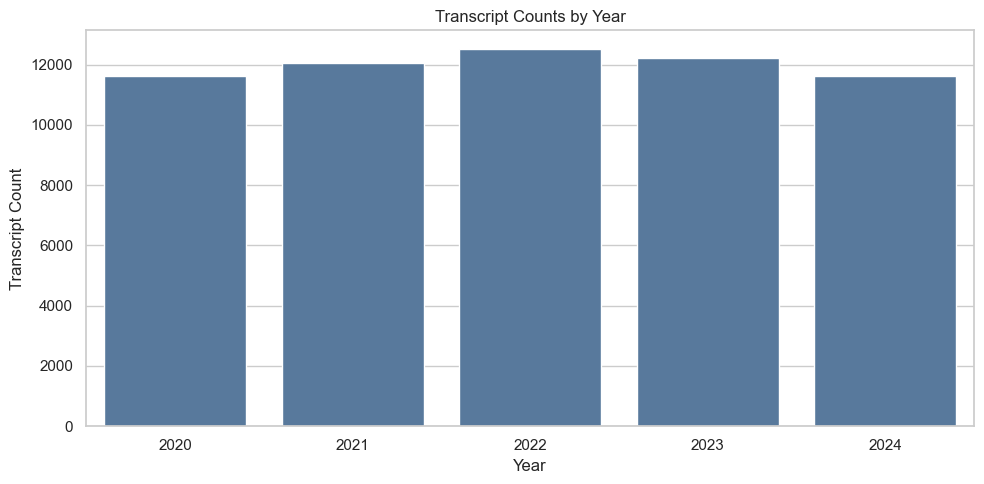

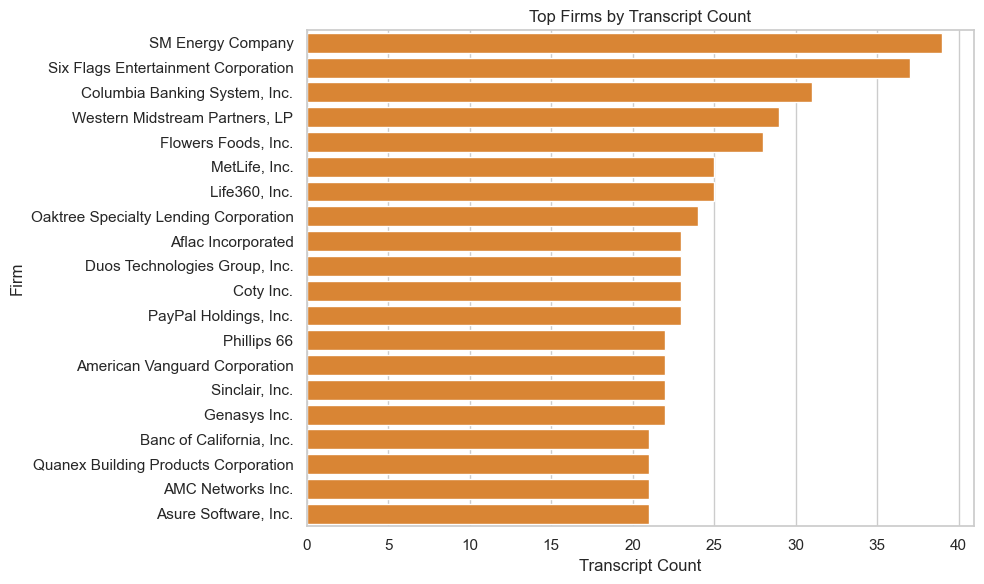

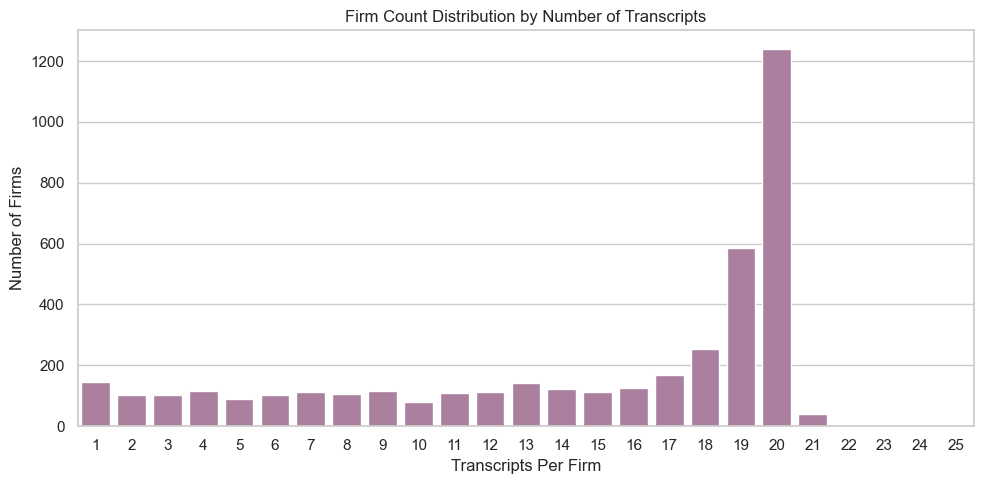

,year,transcript_count
0,2020,11613
1,2021,12043
2,2022,12510
3,2023,12222
4,2024,11616


,metric,value
0,unique_firms,4091.000000
1,mean_transcripts_per_firm,14.667319
2,median_transcripts_per_firm,18.000000
3,p25_transcripts_per_firm,10.000000
4,p75_transcripts_per_firm,20.000000
5,p90_transcripts_per_firm,20.000000
6,max_transcripts_for_one_firm,39.000000


,metric,value
0,total_firms,4091.00000
1,firms_with_exactly_20_transcripts,1239.00000
2,share_of_firms_with_exactly_20_transcripts,0.30286
3,firms_with_more_than_20_transcripts,55.00000


,transcripts_per_firm,firm_count
0,1,145
1,2,102
2,3,101
3,4,114
4,5,89
5,6,101
6,7,111
7,8,106
8,9,116
9,10,81


,companyname,transcript_count
0,SM Energy Company,39
1,Six Flags Entertainment Corporation,37
2,"Columbia Banking System, Inc.",31
3,"Western Midstream Partners, LP",29
4,"Flowers Foods, Inc.",28
5,"MetLife, Inc.",25
6,"Life360, Inc.",25
7,Oaktree Specialty Lending Corporation,24
8,Aflac Incorporated,23
9,"Duos Technologies Group, Inc.",23


In [10]:
counts_by_year = (
    transcripts.assign(year=transcripts[DATE_COLUMN].dt.year)
    .groupby("year")
    .size()
    .rename("transcript_count")
    .reset_index()
    .sort_values("year")
    .reset_index(drop=True)
)

firm_counts = (
    transcripts.groupby(FIRM_COLUMN)
    .size()
    .rename("transcript_count")
    .sort_values(ascending=False)
)

firm_count_distribution = (
    firm_counts.value_counts()
    .sort_index()
    .rename_axis("transcripts_per_firm")
    .reset_index(name="firm_count")
)
firms_exactly_20 = int((firm_counts == 20).sum())
firm_count_cap_note = pd.DataFrame(
    [
        {"metric": "total_firms", "value": int(firm_counts.shape[0])},
        {"metric": "firms_with_exactly_20_transcripts", "value": firms_exactly_20},
        {
            "metric": "share_of_firms_with_exactly_20_transcripts",
            "value": float(firms_exactly_20 / max(int(firm_counts.shape[0]), 1)),
        },
        {"metric": "firms_with_more_than_20_transcripts", "value": int((firm_counts > 20).sum())},
    ]
)

top_firms = firm_counts.head(20).rename_axis(FIRM_COLUMN).reset_index()
firm_count_summary = pd.DataFrame(
    [
        {"metric": "unique_firms", "value": int(firm_counts.shape[0])},
        {"metric": "mean_transcripts_per_firm", "value": float(firm_counts.mean())},
        {"metric": "median_transcripts_per_firm", "value": float(firm_counts.median())},
        {"metric": "p25_transcripts_per_firm", "value": float(firm_counts.quantile(0.25))},
        {"metric": "p75_transcripts_per_firm", "value": float(firm_counts.quantile(0.75))},
        {"metric": "p90_transcripts_per_firm", "value": float(firm_counts.quantile(0.90))},
        {"metric": "max_transcripts_for_one_firm", "value": int(firm_counts.max())},
    ]
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=counts_by_year, x="year", y="transcript_count", color="#4C78A8", ax=ax)
ax.set_title("Transcript Counts by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Transcript Count")
fig.tight_layout()
fig.savefig(figure_path(f"{OUTPUT_PREFIX}_counts_by_year.png"), dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_firms, y=FIRM_COLUMN, x="transcript_count", color="#F58518", ax=ax)
ax.set_title("Top Firms by Transcript Count")
ax.set_xlabel("Transcript Count")
ax.set_ylabel("Firm")
fig.tight_layout()
fig.savefig(figure_path(f"{OUTPUT_PREFIX}_top_firms.png"), dpi=200, bbox_inches="tight")
plt.show()

firm_count_distribution_plot = firm_count_distribution.loc[
    firm_count_distribution["transcripts_per_firm"] <= 25
].copy()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=firm_count_distribution_plot,
    x="transcripts_per_firm",
    y="firm_count",
    color="#B279A2",
    ax=ax,
)
ax.set_title("Firm Count Distribution by Number of Transcripts")
ax.set_xlabel("Transcripts Per Firm")
ax.set_ylabel("Number of Firms")
fig.tight_layout()
fig.savefig(figure_path(f"{OUTPUT_PREFIX}_firm_count_distribution.png"), dpi=200, bbox_inches="tight")
plt.show()

display(counts_by_year)
display(firm_count_summary)
display(firm_count_cap_note)
display(firm_count_distribution.head(25))
display(top_firms)


## Additional Lightweight Supporting EDA

This section adds a small amount of high-value supporting context: transcript-length summaries and a quick note on section availability. No section splitting is attempted here because the cleaned dataset does not yet contain separate prepared-remarks and Q&A fields.


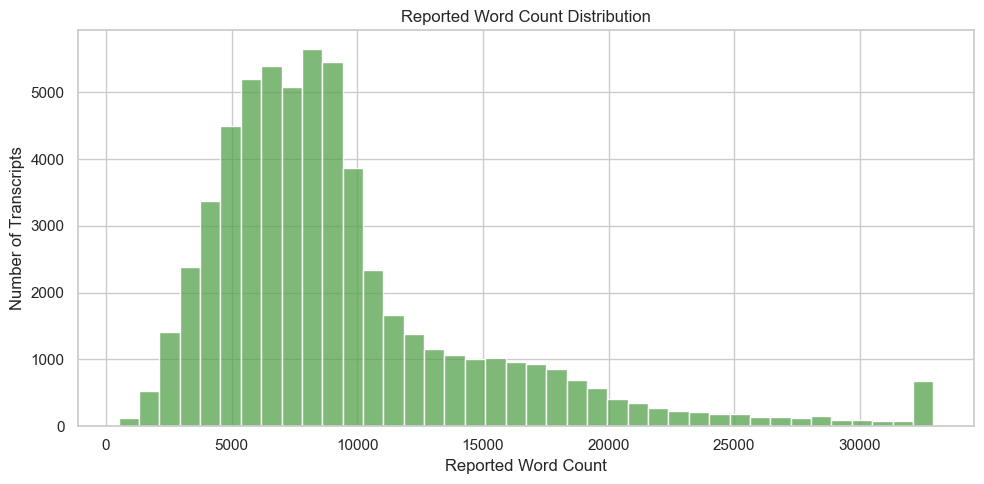

,row_count,non_missing_text_rows,share_non_missing_text,rows_with_reported_word_count,rows_with_reported_character_count
0,60004,60004,1.0,60004,60004


,metric,count,mean,median,p25,p75,max
0,reported_word_count,60004,9575.824612,8094.0,5791.0,10918.5,546840.0
1,reported_character_count,60004,56271.822312,47499.0,34251.5,64010.5,3081358.0


,check,result,note
0,separate prepared remarks / Q&A fields,not present in current cleaned file,Task 2 treats each transcript as one document ...


In [11]:
text_coverage_summary = pd.DataFrame(
    [
        {
            "row_count": int(len(transcripts)),
            "non_missing_text_rows": int(transcripts[TEXT_COLUMN].notna().sum()),
            "share_non_missing_text": float(transcripts[TEXT_COLUMN].notna().mean()),
            "rows_with_reported_word_count": int(transcripts["word_count"].notna().sum()),
            "rows_with_reported_character_count": int(transcripts["transcript_length"].notna().sum()),
        }
    ]
)

word_count_series = pd.to_numeric(transcripts["word_count"], errors="coerce")
char_count_series = pd.to_numeric(transcripts["transcript_length"], errors="coerce")
text_length_summary = pd.DataFrame(
    [
        {"metric": "reported_word_count", "count": int(word_count_series.notna().sum()), "mean": float(word_count_series.mean()), "median": float(word_count_series.median()), "p25": float(word_count_series.quantile(0.25)), "p75": float(word_count_series.quantile(0.75)), "max": float(word_count_series.max())},
        {"metric": "reported_character_count", "count": int(char_count_series.notna().sum()), "mean": float(char_count_series.mean()), "median": float(char_count_series.median()), "p25": float(char_count_series.quantile(0.25)), "p75": float(char_count_series.quantile(0.75)), "max": float(char_count_series.max())},
    ]
)

section_detection_note = pd.DataFrame(
    [
        {
            "check": "separate prepared remarks / Q&A fields",
            "result": "not present in current cleaned file",
            "note": "Task 2 treats each transcript as one document and does not split sections yet.",
        }
    ]
)

plot_word_count = word_count_series.dropna()
plot_word_count = plot_word_count.clip(upper=plot_word_count.quantile(0.99))
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(plot_word_count, bins=40, color="#54A24B", ax=ax)
ax.set_title("Reported Word Count Distribution")
ax.set_xlabel("Reported Word Count")
ax.set_ylabel("Number of Transcripts")
fig.tight_layout()
fig.savefig(figure_path(f"{OUTPUT_PREFIX}_word_count_distribution.png"), dpi=200, bbox_inches="tight")
plt.show()

display(text_coverage_summary)
display(text_length_summary)
display(section_detection_note)

## Theme and Keyword Exploration

This section uses the reusable helpers in `src/features/keyword_counts.py`.

Two complementary views are shown:
- concept dictionaries for interpretable themes such as guidance, dividends, and R&D
- simple bag-of-words tables for common unigrams and bigrams

The concept counts use exact keyword or phrase matching after lowercasing and whitespace normalization.


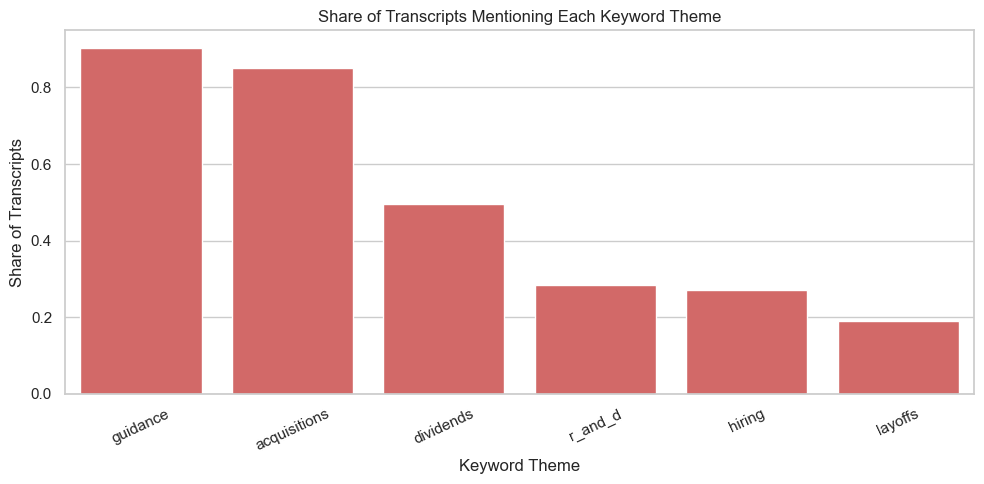

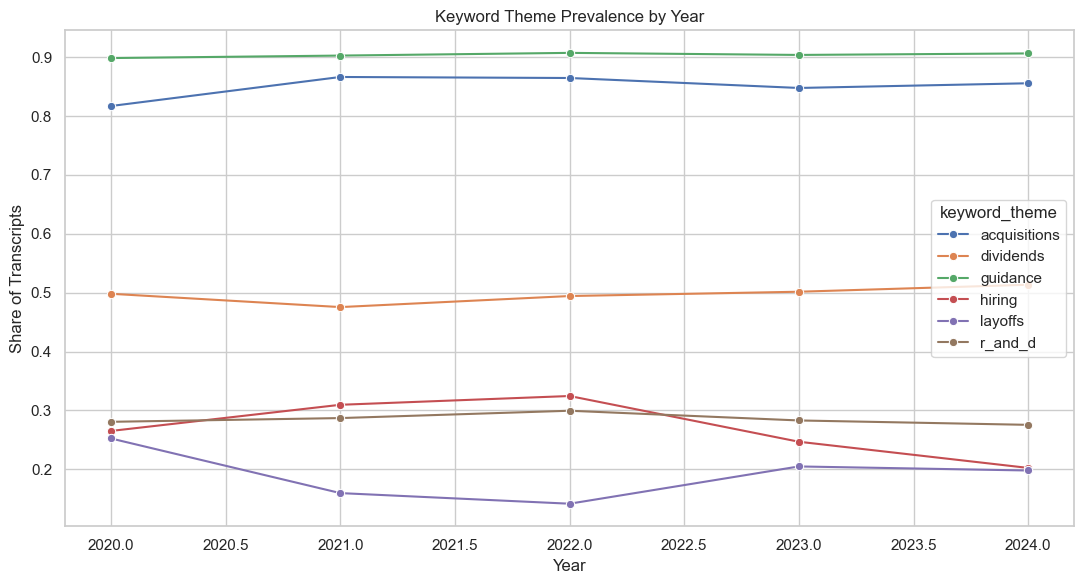

,keyword_theme,total_mentions,transcripts_with_mentions,share_of_transcripts,mean_mentions_per_transcript
0,guidance,714546,54234,0.903840,11.908306
1,acquisitions,581644,51041,0.850627,9.693420
2,dividends,190526,29787,0.496417,3.175222
3,r_and_d,77422,17114,0.285214,1.290281
4,hiring,61814,16227,0.270432,1.030165
5,layoffs,46224,11418,0.190287,0.770349


,year,keyword_theme,transcript_count,total_mentions,transcripts_with_mentions,share_of_transcripts
0,2020,acquisitions,11613,100176,9489,0.817102
1,2021,acquisitions,12043,131875,10434,0.866395
2,2022,acquisitions,12510,130670,10817,0.864668
3,2023,acquisitions,12222,110130,10361,0.847734
4,2024,acquisitions,11616,108793,9940,0.855716
5,2020,dividends,11613,38780,5784,0.498063
6,2021,dividends,12043,37451,5726,0.475463
7,2022,dividends,12510,41375,6183,0.494245
8,2023,dividends,12222,38023,6130,0.501555
9,2024,dividends,11616,34897,5964,0.513430


,companyname,transcript_count,total_mentions,transcripts_with_mentions,share_of_transcripts
0,SM Energy Company,39,416,37,0.948718
1,Six Flags Entertainment Corporation,37,219,36,0.972973
2,"Columbia Banking System, Inc.",31,526,30,0.967742
3,"Western Midstream Partners, LP",29,329,29,1.000000
4,"Flowers Foods, Inc.",28,192,28,1.000000
5,"Life360, Inc.",25,255,24,0.960000
6,"PayPal Holdings, Inc.",23,874,23,1.000000
7,"Duos Technologies Group, Inc.",23,448,23,1.000000
8,"Sinclair, Inc.",22,459,22,1.000000
9,Phillips 66,22,356,22,1.000000


,term,total_count,document_frequency,share_of_documents
0,projects,154043,23963,0.399357
1,equity,127944,23928,0.398773
2,september,108908,23771,0.396157
3,north,118394,23751,0.395824
4,project,129034,23249,0.387458
5,power,118409,23244,0.387374
6,prices,120555,22925,0.382058
7,home,134451,22797,0.379925
8,recovery,106211,22576,0.376242
9,systems,107254,22488,0.374775


,term,total_count,document_frequency,share_of_documents
0,total revenue,47367,14950,0.249150
1,25 million,34009,14803,0.246700
2,customer base,39095,14709,0.245134
3,capital allocation,43180,14620,0.243650
4,quarter compared,33674,14567,0.242767
5,year period,56742,14433,0.240534
6,single digit,47134,14407,0.240101
7,december 31,56271,14112,0.235184
8,diluted share,51089,14028,0.233784
9,quarter end,35850,13811,0.230168


In [12]:
keyword_features = build_keyword_feature_table(
    transcripts,
    keyword_sets=CONCEPT_KEYWORDS,
    text_column=TEXT_COLUMN,
    id_column=ID_COLUMN,
)
keyword_summary = keyword_frequency_summary(keyword_features, id_col=ID_COLUMN)
keyword_by_year = keyword_frequency_by_year(
    transcripts,
    keyword_features,
    date_col=DATE_COLUMN,
    id_col=ID_COLUMN,
)
guidance_by_firm = keyword_frequency_by_firm(
    transcripts,
    keyword_features,
    firm_col=FIRM_COLUMN,
    id_col=ID_COLUMN,
    keyword_theme="guidance",
    top_n=20,
)

unigram_min_df = max(25, int(len(transcripts) * 0.002))
bigram_min_df = max(20, int(len(transcripts) * 0.0015))

top_unigrams = build_term_frequency_table(
    transcripts,
    text_col=TEXT_COLUMN,
    max_features=40,
    min_df=unigram_min_df,
    max_df=0.4,
    ngram_range=(1, 1),
)
top_bigrams = build_term_frequency_table(
    transcripts,
    text_col=TEXT_COLUMN,
    max_features=40,
    min_df=bigram_min_df,
    max_df=0.25,
    ngram_range=(2, 2),
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=keyword_summary,
    x="keyword_theme",
    y="share_of_transcripts",
    color="#E45756",
    ax=ax,
)
ax.set_title("Share of Transcripts Mentioning Each Keyword Theme")
ax.set_xlabel("Keyword Theme")
ax.set_ylabel("Share of Transcripts")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(figure_path(f"{OUTPUT_PREFIX}_keyword_theme_prevalence.png"), dpi=200, bbox_inches="tight")
plt.show()

keyword_year_plot = keyword_by_year.copy()
fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(
    data=keyword_year_plot,
    x="year",
    y="share_of_transcripts",
    hue="keyword_theme",
    marker="o",
    ax=ax,
)
ax.set_title("Keyword Theme Prevalence by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Transcripts")
fig.tight_layout()
fig.savefig(figure_path(f"{OUTPUT_PREFIX}_keyword_theme_prevalence_by_year.png"), dpi=200, bbox_inches="tight")
plt.show()

display(keyword_summary)
display(keyword_by_year)
display(guidance_by_firm)
display(top_unigrams)
display(top_bigrams)

## Preliminary Topic Discovery

This section uses the lightweight topic helpers in `src/features/topic_modeling.py`.

To keep the method simple and tractable, the notebook:
- applies only light preprocessing
- fits a basic sklearn LDA model
- uses a year-balanced sample of documents for topic fitting rather than the full corpus

These topics are exploratory summaries, not final labeled constructs.


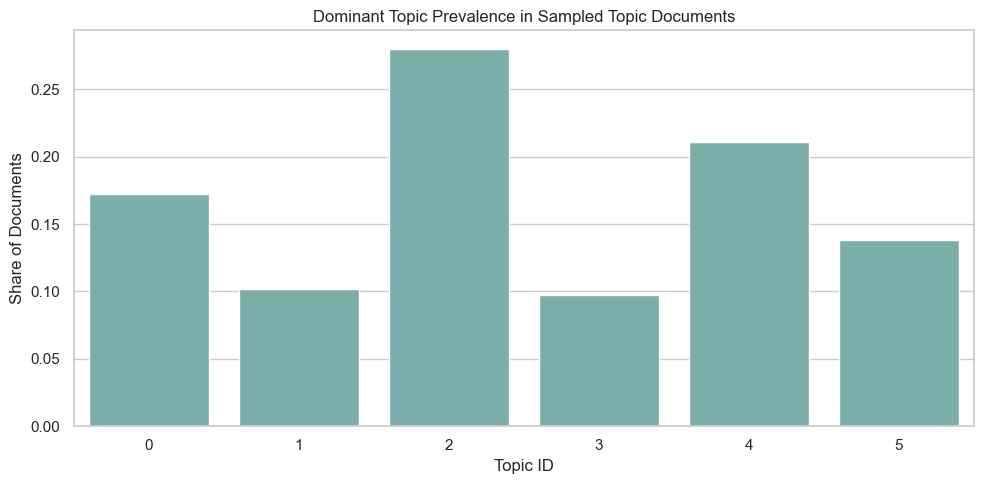

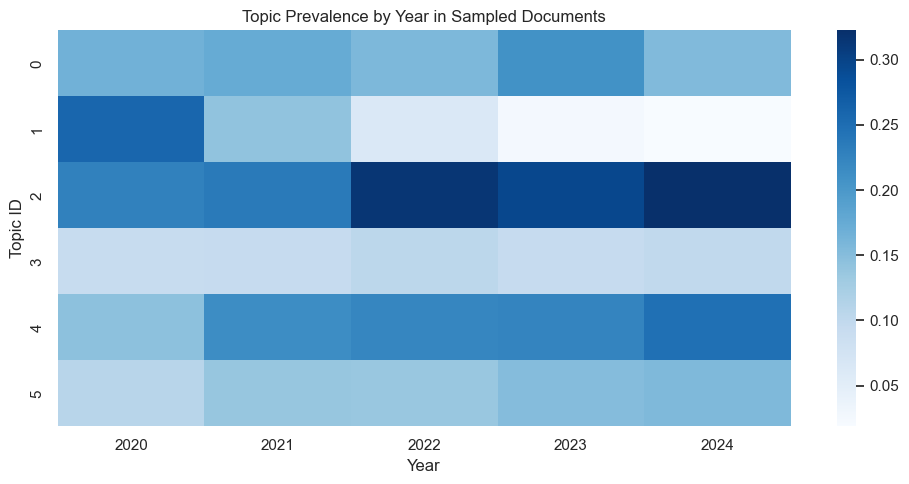

Topic modeling note: this is a lightweight exploratory LDA baseline on a sampled subset of transcripts.


,documents_available_for_topics,documents_used_for_topic_fit,requested_topic_count
0,60004,4000,6


,topic_id,top_terms
0,0,"loan, credit, loans, assets, asset, equity, ba..."
1,1,"2020, covid, 2019, pandemic, fiscal, revenues,..."
2,2,"supply, production, 2023, ebitda, energy, slid..."
3,3,"patients, clinical, study, phase, trial, patie..."
4,4,"platform, services, solutions, clients, ebitda..."
5,5,"consumer, brand, inventory, store, retail, bra..."


,topic_id,document_count,share_of_documents,top_terms
0,0,689,0.17225,"loan, credit, loans, assets, asset, equity, ba..."
1,1,407,0.10175,"2020, covid, 2019, pandemic, fiscal, revenues,..."
2,2,1119,0.27975,"supply, production, 2023, ebitda, energy, slid..."
3,3,390,0.09750,"patients, clinical, study, phase, trial, patie..."
4,4,843,0.21075,"platform, services, solutions, clients, ebitda..."
5,5,552,0.13800,"consumer, brand, inventory, store, retail, bra..."


,year,topic_id,document_count,share_of_year_documents
0,2020,0,133,0.16625
1,2020,1,207,0.25875
2,2020,2,183,0.22875
3,2020,3,74,0.09250
4,2020,4,116,0.14500
5,2020,5,87,0.10875
6,2021,0,140,0.17500
7,2021,1,114,0.14250
8,2021,2,189,0.23625
9,2021,3,76,0.09500


,dominant_topic,dominant_topic_share,transcriptid,ticker,companyname,call_date,text_preview
0,0,0.999826,2942813.0,AINV,MidCap Financial Investment Corporation,2023-11-08,"Good morning, and welcome to the MidCap Financ..."
1,0,0.999683,2781945.0,UCB,"United Community Banks, Inc.",2023-04-19,"Good morning, and welcome to United Community ..."
2,1,0.983956,2297808.0,AESE,Allied Gaming & Entertainment Inc.,2021-05-24,Thank you for standing by. This is the confere...
3,1,0.977743,2122281.0,BIHI,"Xtant Medical Holdings, Inc.",2020-10-29,"Greetings, and welcome to the Xtant Medical's ..."
4,2,0.999287,2874813.0,CBT,Cabot Corporation,2023-08-08,Good day and thank you for standing by. Welcom...
5,2,0.999143,2860005.0,KEX,Kirby Corporation,2023-07-27,"Good day, and thank you for standing by. Welco..."
6,3,0.999818,3243180.0,CYTX,"Plus Therapeutics, Inc.",2024-08-14,"Good afternoon, ladies and gentlemen. Welcome ..."
7,3,0.999809,2542027.0,CYTX,"Plus Therapeutics, Inc.",2022-04-21,"Good afternoon, ladies and gentlemen. Welcome ..."
8,4,0.999478,2899783.0,OKTA,"Okta, Inc.",2023-08-30,"Hi, everybody. Welcome to Okta's Second Quarte..."
9,4,0.999362,3187623.0,CRWD,"CrowdStrike Holdings, Inc.",2024-06-04,"Good day, everyone, and thank you for standing..."


In [13]:
topic_documents = prepare_documents_for_topic_modeling(
    transcripts,
    text_column=TEXT_COLUMN,
    id_column=ID_COLUMN,
    extra_columns=[DATE_COLUMN, TICKER_COLUMN, FIRM_COLUMN],
    output_text_column="clean_text",
    min_characters=250,
)
topic_documents_sample = sample_topic_documents(
    topic_documents,
    max_documents=TOPIC_SAMPLE_SIZE,
    date_column=DATE_COLUMN,
    random_state=42,
)

topic_model_result = fit_lda_topic_model(
    topic_documents_sample,
    text_column="clean_text",
    n_topics=TOPIC_COUNT,
    max_features=1200,
    min_df=max(10, int(len(topic_documents_sample) * 0.01)),
    max_df=0.6,
    ngram_range=(1, 1),
    stop_words="english",
    random_state=42,
    max_iter=10,
)

topic_top_words = extract_top_words_per_topic(
    topic_model_result["model"],
    topic_model_result["vectorizer"],
    n_top_words=12,
)
topic_assignments = assign_dominant_topic(
    topic_model_result["documents_used"],
    topic_model_result["document_topic_matrix"],
    id_column=ID_COLUMN,
)
topic_prevalence = summarize_topic_prevalence(
    topic_assignments,
    date_column=DATE_COLUMN,
)
topic_examples = select_topic_examples(
    topic_assignments,
    text_column=TEXT_COLUMN,
    topic_column="dominant_topic",
    score_column="dominant_topic_share",
    id_column=ID_COLUMN,
    n_examples_per_topic=2,
)
topic_sample_summary = pd.DataFrame(
    [
        {
            "documents_available_for_topics": int(len(topic_documents)),
            "documents_used_for_topic_fit": int(len(topic_documents_sample)),
            "requested_topic_count": int(TOPIC_COUNT),
        }
    ]
)
topic_summary = topic_prevalence["overall"].merge(topic_top_words, on="topic_id", how="left")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=topic_summary, x="topic_id", y="share_of_documents", color="#72B7B2", ax=ax)
ax.set_title("Dominant Topic Prevalence in Sampled Topic Documents")
ax.set_xlabel("Topic ID")
ax.set_ylabel("Share of Documents")
fig.tight_layout()
fig.savefig(figure_path(f"{OUTPUT_PREFIX}_topic_prevalence.png"), dpi=200, bbox_inches="tight")
plt.show()

if not topic_prevalence["by_year"].empty:
    topic_heatmap = topic_prevalence["by_year"].pivot(
        index="topic_id",
        columns="year",
        values="share_of_year_documents",
    ).fillna(0)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(topic_heatmap, cmap="Blues", ax=ax)
    ax.set_title("Topic Prevalence by Year in Sampled Documents")
    ax.set_xlabel("Year")
    ax.set_ylabel("Topic ID")
    fig.tight_layout()
    fig.savefig(figure_path(f"{OUTPUT_PREFIX}_topic_prevalence_by_year.png"), dpi=200, bbox_inches="tight")
    plt.show()
else:
    topic_heatmap = pd.DataFrame()

print("Topic modeling note: this is a lightweight exploratory LDA baseline on a sampled subset of transcripts.")
display(topic_sample_summary)
display(topic_top_words)
display(topic_summary)
display(topic_prevalence["by_year"])
display(topic_examples)

## Save Outputs

This section writes the main EDA tables, topic tables, figures, and reusable intermediate artifacts to stable project paths. All major tables and figures have already been shown inline above.


In [14]:
tables_to_save = {
    "counts_by_year": counts_by_year,
    "firm_count_summary": firm_count_summary,
    "firm_count_cap_note": firm_count_cap_note,
    "firm_count_distribution": firm_count_distribution,
    "top_firms": top_firms,
    "text_coverage_summary": text_coverage_summary,
    "text_length_summary": text_length_summary,
    "section_detection_note": section_detection_note,
    "keyword_summary": keyword_summary,
    "keyword_by_year": keyword_by_year,
    "guidance_by_firm": guidance_by_firm,
    "top_unigrams": top_unigrams,
    "top_bigrams": top_bigrams,
    "topic_sample_summary": topic_sample_summary,
    "topic_top_words": topic_top_words,
    "topic_summary": topic_summary,
    "topic_prevalence_overall": topic_prevalence["overall"],
    "topic_prevalence_by_year": topic_prevalence["by_year"],
    "topic_examples": topic_examples,
}

for name, table in tables_to_save.items():
    table.to_csv(table_path(f"{OUTPUT_PREFIX}_{name}.csv"), index=False)

keyword_features_path = interim_data_path(f"{OUTPUT_PREFIX}_keyword_features.parquet")
topic_assignments_path = interim_data_path(f"{OUTPUT_PREFIX}_topic_assignments_sample.parquet")
keyword_features.to_parquet(keyword_features_path, index=False)
topic_assignments.to_parquet(topic_assignments_path, index=False)

save_manifest = pd.DataFrame(
    [
        {"artifact_type": "table", "artifact_name": name, "path": str(table_path(f"{OUTPUT_PREFIX}_{name}.csv"))}
        for name in tables_to_save
    ]
    + [
        {"artifact_type": "figure", "artifact_name": "counts_by_year", "path": str(figure_path(f"{OUTPUT_PREFIX}_counts_by_year.png"))},
        {"artifact_type": "figure", "artifact_name": "top_firms", "path": str(figure_path(f"{OUTPUT_PREFIX}_top_firms.png"))},
        {"artifact_type": "figure", "artifact_name": "firm_count_distribution", "path": str(figure_path(f"{OUTPUT_PREFIX}_firm_count_distribution.png"))},
        {"artifact_type": "figure", "artifact_name": "word_count_distribution", "path": str(figure_path(f"{OUTPUT_PREFIX}_word_count_distribution.png"))},
        {"artifact_type": "figure", "artifact_name": "keyword_theme_prevalence", "path": str(figure_path(f"{OUTPUT_PREFIX}_keyword_theme_prevalence.png"))},
        {"artifact_type": "figure", "artifact_name": "keyword_theme_prevalence_by_year", "path": str(figure_path(f"{OUTPUT_PREFIX}_keyword_theme_prevalence_by_year.png"))},
        {"artifact_type": "figure", "artifact_name": "topic_prevalence", "path": str(figure_path(f"{OUTPUT_PREFIX}_topic_prevalence.png"))},
        {"artifact_type": "figure", "artifact_name": "topic_prevalence_by_year", "path": str(figure_path(f"{OUTPUT_PREFIX}_topic_prevalence_by_year.png"))},
        {"artifact_type": "dataset", "artifact_name": "keyword_features", "path": str(keyword_features_path)},
        {"artifact_type": "dataset", "artifact_name": "topic_assignments_sample", "path": str(topic_assignments_path)},
    ]
)

display(save_manifest)
display(firm_count_cap_note)
display(keyword_summary)
display(topic_summary)


,artifact_type,artifact_name,path
0,table,counts_by_year,C:\Users\javed\Documents\Projects\Analytical F...
1,table,firm_count_summary,C:\Users\javed\Documents\Projects\Analytical F...
2,table,firm_count_cap_note,C:\Users\javed\Documents\Projects\Analytical F...
3,table,firm_count_distribution,C:\Users\javed\Documents\Projects\Analytical F...
4,table,top_firms,C:\Users\javed\Documents\Projects\Analytical F...
5,table,text_coverage_summary,C:\Users\javed\Documents\Projects\Analytical F...
6,table,text_length_summary,C:\Users\javed\Documents\Projects\Analytical F...
7,table,section_detection_note,C:\Users\javed\Documents\Projects\Analytical F...
8,table,keyword_summary,C:\Users\javed\Documents\Projects\Analytical F...
9,table,keyword_by_year,C:\Users\javed\Documents\Projects\Analytical F...


,metric,value
0,total_firms,4091.00000
1,firms_with_exactly_20_transcripts,1239.00000
2,share_of_firms_with_exactly_20_transcripts,0.30286
3,firms_with_more_than_20_transcripts,55.00000


,keyword_theme,total_mentions,transcripts_with_mentions,share_of_transcripts,mean_mentions_per_transcript
0,guidance,714546,54234,0.903840,11.908306
1,acquisitions,581644,51041,0.850627,9.693420
2,dividends,190526,29787,0.496417,3.175222
3,r_and_d,77422,17114,0.285214,1.290281
4,hiring,61814,16227,0.270432,1.030165
5,layoffs,46224,11418,0.190287,0.770349


,topic_id,document_count,share_of_documents,top_terms
0,0,689,0.17225,"loan, credit, loans, assets, asset, equity, ba..."
1,1,407,0.10175,"2020, covid, 2019, pandemic, fiscal, revenues,..."
2,2,1119,0.27975,"supply, production, 2023, ebitda, energy, slid..."
3,3,390,0.09750,"patients, clinical, study, phase, trial, patie..."
4,4,843,0.21075,"platform, services, solutions, clients, ebitda..."
5,5,552,0.13800,"consumer, brand, inventory, store, retail, bra..."


## Final Notebook Summary

This exploratory pass is meant to answer three practical questions:
- how the cleaned transcript corpus is distributed across years and firms
- which simple themes appear common enough to study later
- whether a lightweight topic baseline reveals recurring patterns worth refining

The outputs from this notebook should be treated as descriptive steering artifacts rather than final validated constructs. Later work can build on these saved tables and the cleaned corpus without redoing the raw-data audit.
